In [ ]:
# Single Layer Perceptron from Scratch

## Objective

Implement a fully connected Neural network using only NumPy.

## Topics

- Parameter initialization
- Cost computation
- Forward propagation
- Backpropagation
- Gradient descent
- Prediction

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from utilities import*
from sklearn.decomposition import PCA

In [113]:
def initialisation (X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [114]:
def model(X, W, b):
    Z = X.dot(W) + b
    # print(Z.min())
    A = 1 / (1 + np.exp(-Z))
    return A

In [115]:
def logloss(A, y):
    #Bonne pratique pour eviter de calculer des log en 0
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A+epsilon) - (1 - y) * np.log(1 - A+epsilon))

In [116]:
def compute_gradients(A,X,y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [117]:
def update_parameters(W, b, dw, db, lr):
    W = W - lr * dw
    b = b - lr * db
    return W, b

In [118]:
def predict(X,W,b):
    A = model(X, W, b)
    # print(A)
    return A>0.5

In [120]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X/255.0
    return X

In [121]:
def single_layer_perceptron(X_train, y_train, X_test, y_test, lr=0.01, nb_iter=1000):
    W, b = initialisation(X_train)
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for i in tqdm(range(nb_iter)):
        # Forward train
        A_train = model(X_train, W, b)
        train_losses.append(logloss(A_train, y_train))
        y_pred_train = (A_train > 0.5).astype(int)
        train_accs.append(accuracy_score(y_train, y_pred_train))

        # Forward test
        A_test = model(X_test, W, b)
        test_losses.append(logloss(A_test, y_test))
        y_pred_test = (A_test > 0.5).astype(int)
        test_accs.append(accuracy_score(y_test, y_pred_test))

        # Gradients + update
        dW, db = compute_gradients(A_train, X_train, y_train)
        W, b = update_parameters(W, b, dW, db, lr)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return W, b


In [130]:
X_train, y_train, X_test, y_test = load_data()
X_train = preprocess(X_train)
X_test = preprocess(X_test)

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 279.63it/s]


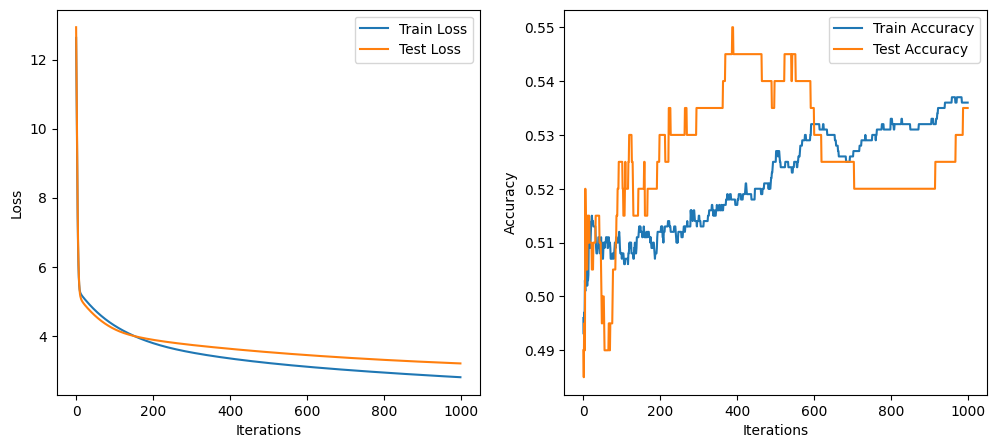

In [129]:
W, b = single_layer_perceptron(X_train, y_train, X_test, y_test, lr=0.01, nb_iter=1000)